This notebook has demo of the function on Les Miserables data. It is sufficiently sized so we could clearly see the visuals so they can be used in the research paper when required.

## Dataset: Rhesus Brain Network

This dataset is based on Victor Hugo's novel *Les Misérables*, compiled by 
Donald Knuth (1993) as part of *The Stanford GraphBase*.

### Graph Properties
- **Vertices (77):** characters in the novel
- **Edges (254):** two characters are connected if they appear in the same chapter
- **Undirected:** co-appearance is a symmetric relationship
- **Unweighted:** edges represent existence of co-appearance, not frequency

### Structure
The most connected node is **Valjean** — the protagonist who appears in nearly 
every chapter and interacts with almost every other character. Other high-degree 
nodes include Javert, Fantine, and Cosette.

### Interpretation as a Flow Network
For our purposes we treat this as a flow network — influence or information 
flowing between characters:
- **Γ_in:** major hub characters (high degree)
- **Γ_out:** peripheral characters (low degree, few appearances)
- **Q:** measures how much influence propagates from central characters 
to the periphery through the network

In [66]:
from functions import *

In [16]:
from functions import *
import networkx as nx
import numpy as np
from scipy.linalg import eigh
import matplotlib.pyplot as plt
from tqdm import tqdm

# visualise

In [21]:
edges, n_vertices, edge_weights = load_graph("./bn-macaque-rhesus_brain_2.edges")

✓ Loaded: ./bn-macaque-rhesus_brain_2.edges
  Vertices : 90
  Edges    : 582
  Weighted : no



Saved as rhesus_brain_viz.png


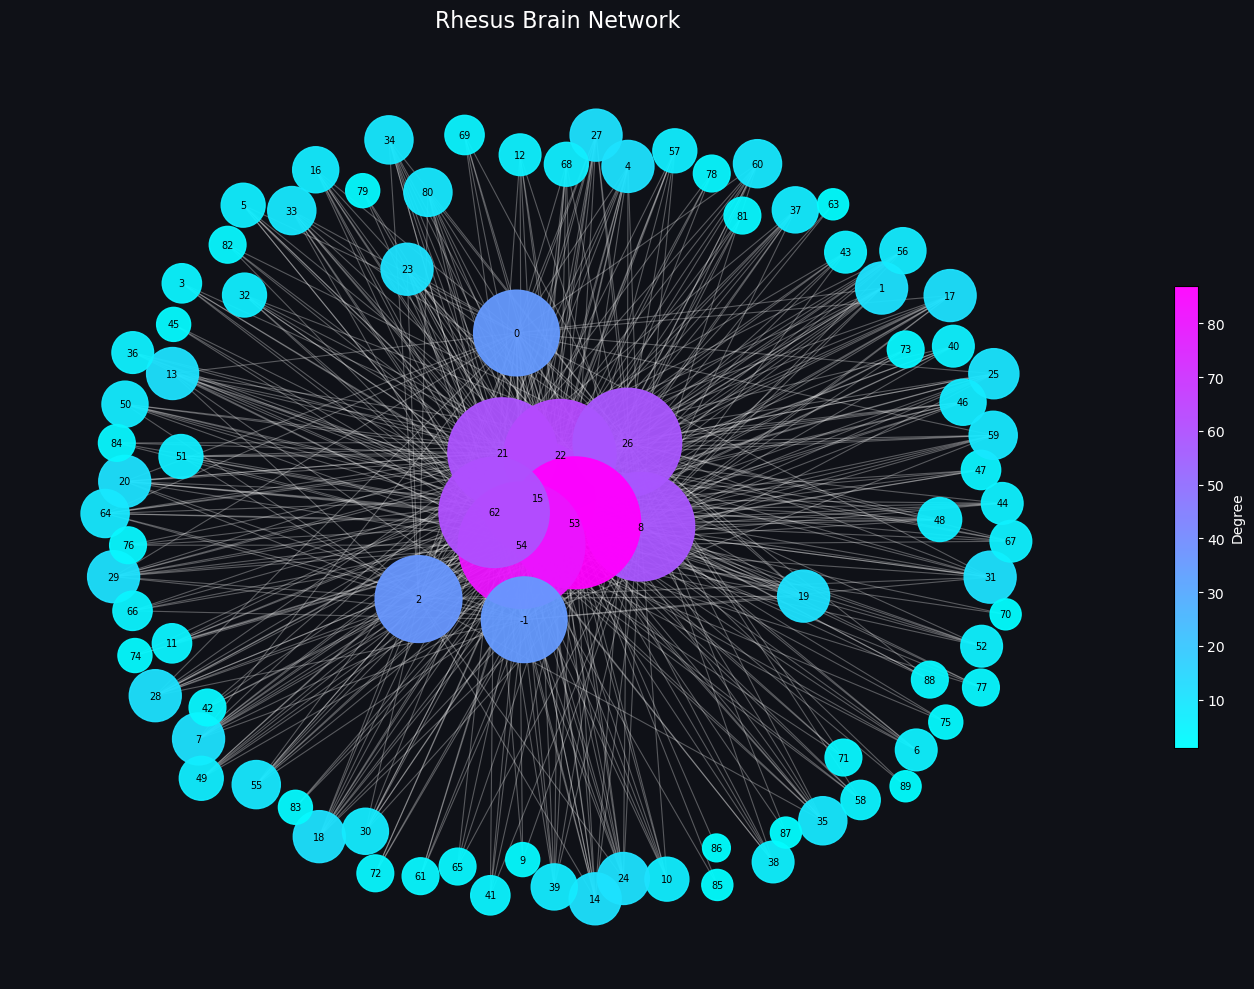

In [23]:
# Paper version
visualize_graph_2d(edges, n_vertices, title="Rhesus Brain Network", save_as="rhesus_brain_viz.png")

# Phase 0

In [25]:
print(f"Vertices : {n_vertices}")
print(f"Edges    : {len(edges)}")

Vertices : 90
Edges    : 582


# Phase 1

In [27]:
A, D, L = build_graph_matrices(edges, n_vertices, edge_weights)

✓ Phase 1 complete: A, D, L built and verified
  Matrix size : 90 x 90
  Degree range: [1, 87]



# Phase 2

In [29]:
# Phase 2: Compute lambda_min and build shifted Laplacian
lambda_min = compute_lambda_min(L, D)
L_sigma    = build_shifted_laplacian(L, D, lambda_min, sigma_squared=0.25)

✓ lambda_min = 0.633608
✓ Phase 2 complete: L_sigma built (sigma^2 = 0.25)
  Smallest eigenvalue of L_sigma: 1.135737



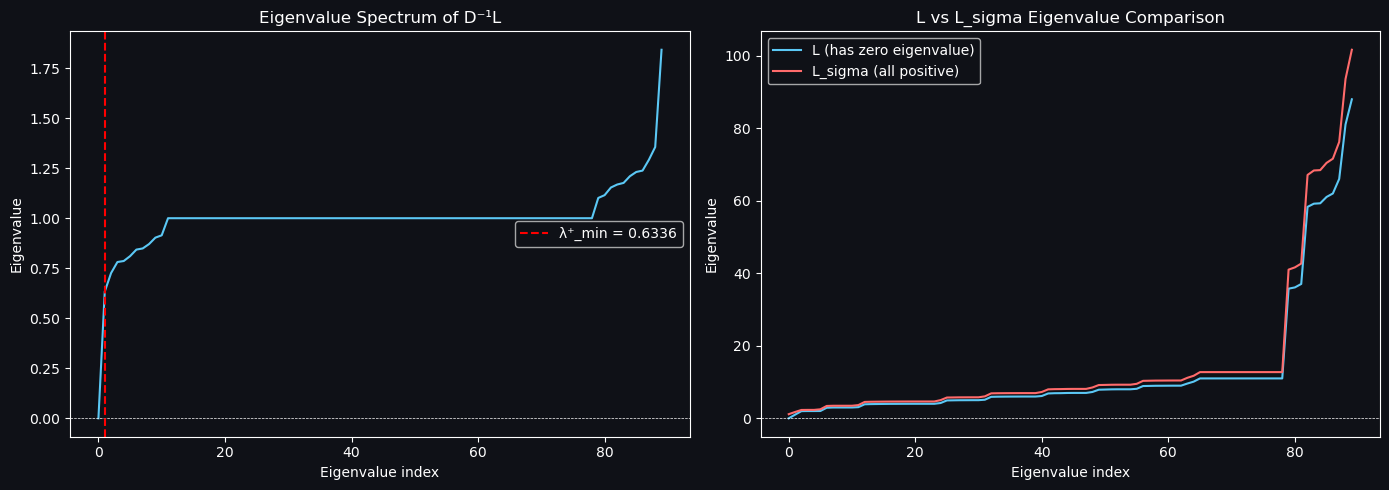

λ⁺_min = 0.633608
Smallest eigenvalue of L_sigma = 1.135737 (should be > 0)


In [60]:
# phase 2 visual
# Compute all eigenvalues of D^{-1}L
eigenvalues, _ = eigh(L, D)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#0f1117")

for ax in axes:
    ax.set_facecolor("#0f1117")
    ax.tick_params(colors="white")
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")
    ax.title.set_color("white")
    for spine in ax.spines.values():
        spine.set_edgecolor("white")

# Plot 1: full eigenvalue spectrum
axes[0].plot(eigenvalues, color="#5bc8f5", linewidth=1.5)
axes[0].axhline(0, color="white", linewidth=0.5, linestyle="--")
axes[0].axvline(1, color="red", linewidth=1.5, linestyle="--",
                label=f"λ⁺_min = {lambda_min:.4f}")
axes[0].set_xlabel("Eigenvalue index")
axes[0].set_ylabel("Eigenvalue")
axes[0].set_title("Eigenvalue Spectrum of D⁻¹L")
axes[0].legend(facecolor="#0f1117", labelcolor="white")

# Plot 2: compare L vs L_sigma eigenvalues
eig_L      = np.linalg.eigvalsh(L)
eig_Lsigma = np.linalg.eigvalsh(L_sigma)

axes[1].plot(eig_L,      color="#5bc8f5", linewidth=1.5, label="L (has zero eigenvalue)")
axes[1].plot(eig_Lsigma, color="#ff6b6b", linewidth=1.5, label="L_sigma (all positive)")
axes[1].axhline(0, color="white", linewidth=0.5, linestyle="--")
axes[1].set_xlabel("Eigenvalue index")
axes[1].set_ylabel("Eigenvalue")
axes[1].set_title("L vs L_sigma Eigenvalue Comparison")
axes[1].legend(facecolor="#0f1117", labelcolor="white")

plt.tight_layout()
plt.savefig("rhesus_phase2.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"λ⁺_min = {lambda_min:.6f}")
print(f"Smallest eigenvalue of L_sigma = {eig_Lsigma[0]:.6f} (should be > 0)")

# Phase 3

In [31]:
# set seed for reproducibility
np.random.seed(42)

# run phase 3
u, B, cho_cache = run_phase3(L_sigma, lambda_min, edges, n_vertices)

✓ Phase 3 complete: correlated field u generated
  u range: [-0.6741, 0.5550]



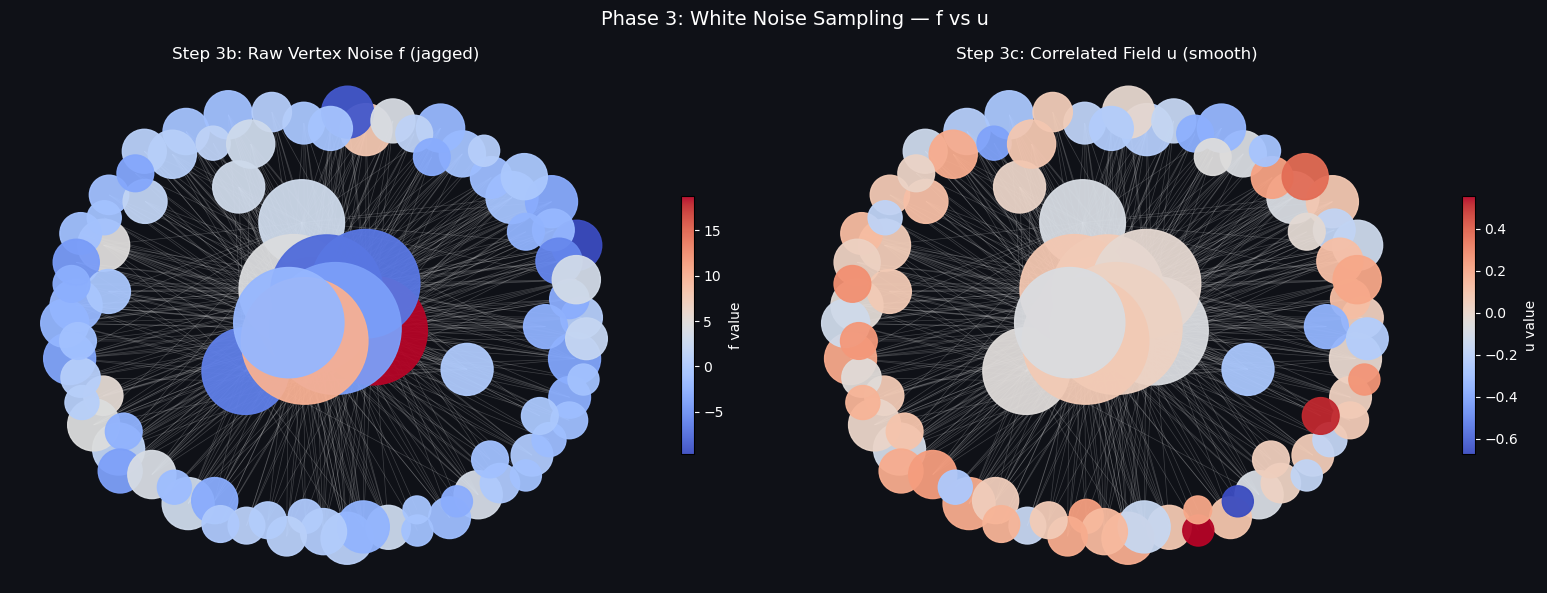

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor("#0f1117")

for ax in axes:
    ax.set_facecolor("#0f1117")
    ax.axis("off")

G_vis = nx.Graph()
G_vis.add_nodes_from(range(n_vertices))  # force 0-indexed nodes
G_vis.add_edges_from(edges)

degrees_vis = dict(G_vis.degree())
pos         = nx.spring_layout(G_vis, seed=42, k=2)
nodelist    = list(range(n_vertices))    # explicit 0-indexed nodelist
node_sizes  = [300 + degrees_vis[v] * 100 for v in nodelist]

# Left: f (raw vertex noise — jagged)
f_demo = B @ np.random.randn(len(edges))
nc1 = nx.draw_networkx_nodes(G_vis, pos, ax=axes[0], nodelist=nodelist,
                              node_size=node_sizes,
                              node_color=[f_demo[v] for v in nodelist],
                              cmap=plt.cm.coolwarm, alpha=0.95)
nx.draw_networkx_edges(G_vis, pos, ax=axes[0], edge_color="white", width=0.5, alpha=0.2)
cb1 = plt.colorbar(nc1, ax=axes[0], shrink=0.5)
cb1.set_label("f value", color="white")
cb1.ax.yaxis.set_tick_params(color="white")
plt.setp(cb1.ax.yaxis.get_ticklabels(), color="white")
axes[0].set_title("Step 3b: Raw Vertex Noise f (jagged)", color="white", fontsize=12)

# Right: u (correlated field — smooth)
nc2 = nx.draw_networkx_nodes(G_vis, pos, ax=axes[1], nodelist=nodelist,
                              node_size=node_sizes,
                              node_color=[u[v] for v in nodelist],
                              cmap=plt.cm.coolwarm, alpha=0.95)
nx.draw_networkx_edges(G_vis, pos, ax=axes[1], edge_color="white", width=0.5, alpha=0.2)
cb2 = plt.colorbar(nc2, ax=axes[1], shrink=0.5)
cb2.set_label("u value", color="white")
cb2.ax.yaxis.set_tick_params(color="white")
plt.setp(cb2.ax.yaxis.get_ticklabels(), color="white")
axes[1].set_title("Step 3c: Correlated Field u (smooth)", color="white", fontsize=12)

plt.suptitle("Phase 3: White Noise Sampling — f vs u", color="white", fontsize=14)
plt.tight_layout()
plt.savefig("rhesus_phase3.png", dpi=150, bbox_inches="tight")
plt.show()

# Phase 4

In [33]:
k = compute_permeability(u, edges, edge_weights)

✓ Phase 4 complete: permeabilities computed
  min k_e : 0.7067
  max k_e : 1.3645
  mean k_e: 1.0043



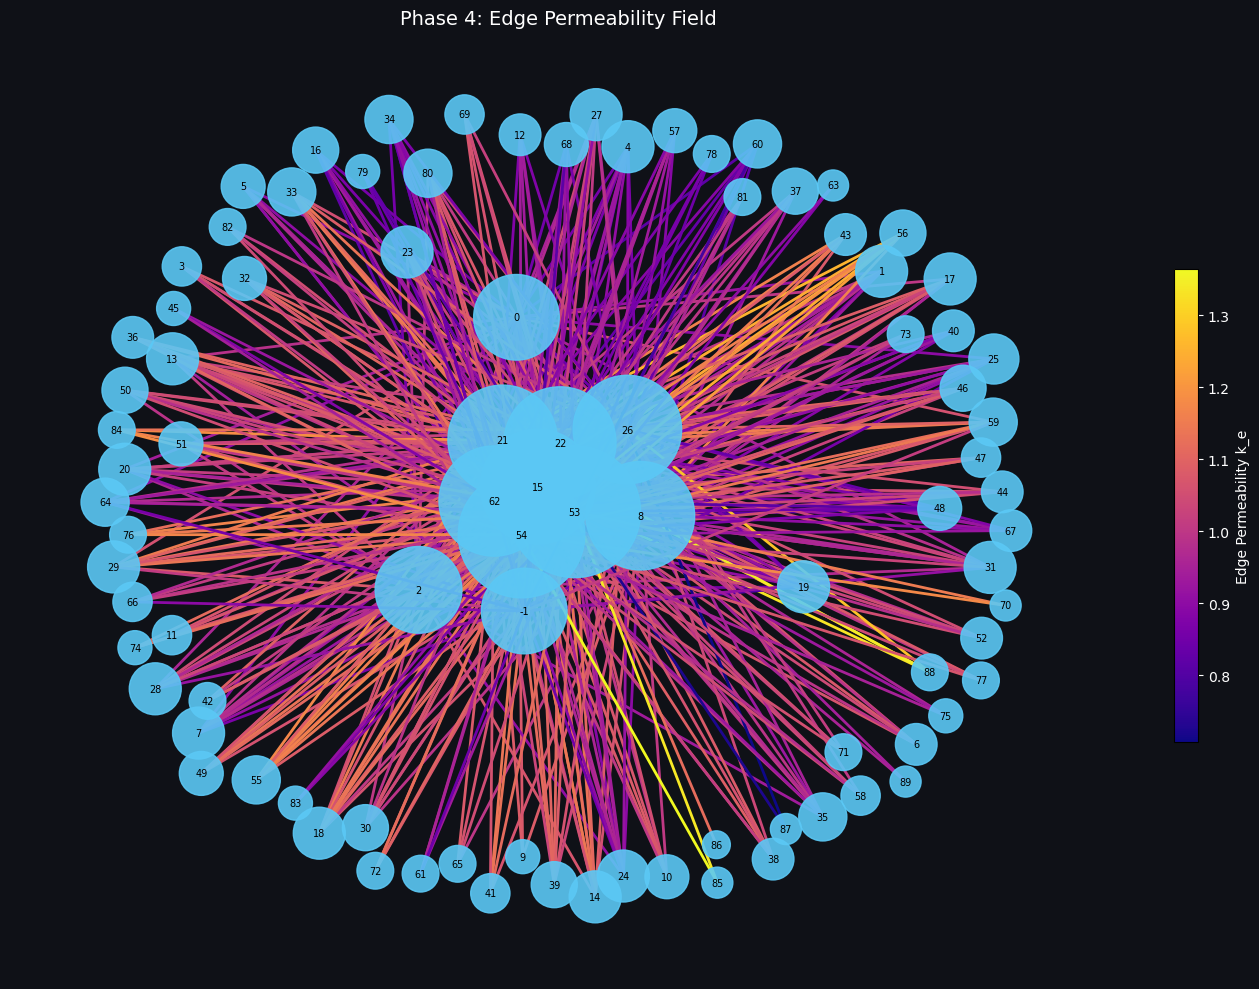

In [62]:
# Visualize permeability on edges
G_vis2 = nx.Graph()
G_vis2.add_nodes_from(range(n_vertices))
for (i,j) in edges:
    G_vis2.add_edge(i, j, weight=k[(i,j)])

weights     = [G_vis2[i][j]['weight'] for i,j in G_vis2.edges()]
node_sizes2 = [300 + degrees_vis[v] * 100 for v in G_vis2.nodes()]

fig, ax = plt.subplots(figsize=(14, 10))
fig.patch.set_facecolor("#0f1117")
ax.set_facecolor("#0f1117")

edges_drawn = nx.draw_networkx_edges(G_vis2, pos, ax=ax, edge_color=weights,
                                      edge_cmap=plt.cm.plasma, width=2,
                                      edge_vmin=min(weights), edge_vmax=max(weights))
nc3 = nx.draw_networkx_nodes(G_vis2, pos, ax=ax, node_size=node_sizes2,
                              node_color="#5bc8f5", alpha=0.9)

# label nodes
nx.draw_networkx_labels(G_vis2, pos, ax=ax, font_color="black", font_size=7)


sm = plt.cm.ScalarMappable(cmap=plt.cm.plasma,
                            norm=plt.Normalize(vmin=min(weights), vmax=max(weights)))
cb = plt.colorbar(sm, ax=ax, shrink=0.5)
cb.set_label("Edge Permeability k_e", color="white")
cb.ax.yaxis.set_tick_params(color="white")
plt.setp(cb.ax.yaxis.get_ticklabels(), color="white")

ax.set_title("Phase 4: Edge Permeability Field", color="white", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.savefig("rhesus_phase4.png", dpi=150, bbox_inches="tight")
plt.show()

# Phase 5

## What


Phase 5 simulates fluid flow through the graph using the permeability 
field **k** computed in Phase 4.

### Step 5a: Build Weighted Laplacian

We build the weighted Laplacian:

$$L_k = \sum_{e=(i,j) \in E} k_e \mathbf{d}_e \mathbf{d}_e^T$$

This is the same structure as **L** from Phase 1, except each edge 
contributes proportionally to its permeability $k_e$ instead of 1. 
High permeability edges dominate, low permeability edges barely contribute.

### Step 5b: Set Boundary Conditions

We prescribe pressure values on two sets of vertices:

- $\Gamma_{in}$ — inlet vertices, pressure $p = 1$ (fluid source)
- $\Gamma_{out}$ — outlet vertices, pressure $p = 0$ (fluid sink)

For the Les Misérables network:
- $\Gamma_{in}$ = top 5 highest degree characters (Valjean and other hubs)
- $\Gamma_{out}$ = top 5 lowest degree characters (peripheral characters)

### Step 5c: Solve for Pressure Field

We solve the reduced system on interior vertices:

$$L_k \mathbf{p} = \mathbf{b}$$

The solution $\mathbf{p}$ is a pressure value at every vertex. 
Flow along each edge is:

$$\text{flow}_{ij} = k_e \times (p_i - p_j)$$

High $k_e$ edges carry more flow. Low $k_e$ edges are bottlenecks.

### Sanity Check
Interior pressure values should satisfy:

$$0 \leq p_v \leq 1 \quad \forall v \notin \Gamma_{in} \cup \Gamma_{out}$$

In [35]:
def build_weighted_laplacian(edges, n_vertices, k):
    """
    Build the weighted Laplacian L_k = sum_e k_e * d_e * d_e^T.
    Same structure as L but edge contributions scaled by permeability k_e.

    Parameters
    ----------
    edges      : list of (i, j) tuples
    n_vertices : int
    k          : dict of {(i,j): k_e} — from Phase 4

    Returns
    -------
    L_k : np.ndarray (n x n)
    """
    L_k = np.zeros((n_vertices, n_vertices))
    for (i, j) in edges:
        k_e = k.get((i,j), k.get((j,i), 1.0))
        L_k[i, i] += k_e
        L_k[j, j] += k_e
        L_k[i, j] -= k_e
        L_k[j, i] -= k_e
    return L_k

In [37]:
def solve_darcy(L_k, n_vertices, gamma_in, gamma_out, p_in=1.0, p_out=0.0):
    """
    Solve the Darcy flow problem L_k p = b with boundary conditions.
    Prescribed pressure p_in on gamma_in, p_out on gamma_out.
    Interior vertices are solved via the reduced system.

    Parameters
    ----------
    L_k       : np.ndarray (n x n) — weighted Laplacian from Phase 5
    n_vertices: int
    gamma_in  : list of int — inlet vertex indices
    gamma_out : list of int — outlet vertex indices
    p_in      : float — inlet pressure (default 1.0)
    p_out     : float — outlet pressure (default 0.0)

    Returns
    -------
    p : np.ndarray (n_vertices,) — pressure at every vertex
    """
    p = np.zeros(n_vertices)
    for v in gamma_in:
        p[v] = p_in
    for v in gamma_out:
        p[v] = p_out

    boundary = set(gamma_in) | set(gamma_out)
    interior = [v for v in range(n_vertices) if v not in boundary]

    L_interior = L_k[np.ix_(interior, interior)]
    L_boundary = L_k[np.ix_(interior, list(boundary))]
    p_boundary = p[list(boundary)]
    rhs        = -L_boundary @ p_boundary
    p_interior = np.linalg.solve(L_interior, rhs)

    for idx, v in enumerate(interior):
        p[v] = p_interior[idx]

    print("✓ Phase 5 complete: pressure field solved")
    print(f"  pressure range: [{p.min():.4f}, {p.max():.4f}]")
    print()
    return p

In [39]:
degrees_arr = A.sum(axis=1)

# gamma_in = top 5 highest degree nodes (most connected brain regions — processing hubs)
# gamma_out = top 5 lowest degree nodes (least connected — peripheral regions)
gamma_in  = list(np.argsort(degrees_arr)[-5:])
gamma_out = list(np.argsort(degrees_arr)[:5])

print(f"gamma_in  (hub regions)       : {gamma_in}")
print(f"gamma_out (peripheral regions): {gamma_out}")
print(f"  inlet degrees : {[int(degrees_arr[v]) for v in gamma_in]}")
print(f"  outlet degrees: {[int(degrees_arr[v]) for v in gamma_out]}")

gamma_in  (hub regions)       : [62, 22, 15, 54, 53]
gamma_out (peripheral regions): [86, 85, 70, 63, 87]
  inlet degrees : [60, 61, 65, 80, 87]
  outlet degrees: [1, 2, 2, 2, 2]


In [41]:
# weighted laplacian for les miserables data
L_k = build_weighted_laplacian(edges, n_vertices, k)

In [64]:
import plotly.graph_objects as go
import matplotlib.colors as mcolors

def visualize_darcy_plotly(edges, n_vertices, p, gamma_in, gamma_out, title="Phase 5: Pressure Field"):
    """
    Interactive Plotly visualization of pressure field p.
    Node color reflects pressure value.
    Gamma_in highlighted in red, Gamma_out in green.
    Hover over nodes to see pressure value and degree.
    """
    G = nx.Graph()
    G.add_nodes_from(range(n_vertices))
    G.add_edges_from(edges)

    degrees  = dict(G.degree())
    pos      = nx.spring_layout(G, seed=42, k=2)

    # normalize pressure for colormap
    norm  = mcolors.Normalize(vmin=0, vmax=1)
    cmap  = plt.cm.RdYlBu

    # edge traces
    edge_x, edge_y = [], []
    for (i, j) in G.edges():
        x0, y0 = pos[i]
        x1, y1 = pos[j]
        edge_x += [x0, x1, None]
        edge_y += [y0, y1, None]

    edge_trace = go.Scatter(
        x=edge_x, y=edge_y,
        mode='lines',
        line=dict(width=0.8, color='rgba(255,255,255,0.2)'),
        hoverinfo='none',
        showlegend=False
    )

    # interior node trace — colored by pressure
    interior    = [v for v in G.nodes() if v not in gamma_in and v not in gamma_out]
    int_x       = [pos[v][0] for v in interior]
    int_y       = [pos[v][1] for v in interior]
    int_colors  = [p[v] for v in interior]
    int_sizes   = [10 + degrees[v] * 5 for v in interior]
    int_text    = [f"Vertex {v}<br>Degree: {degrees[v]}<br>Pressure: {p[v]:.4f}" for v in interior]

    interior_trace = go.Scatter(
        x=int_x, y=int_y,
        mode='markers',
        hoverinfo='text',
        text=int_text,
        marker=dict(
            size=int_sizes,
            color=int_colors,
            colorscale='RdYlBu',
            cmin=0, cmax=1,
            colorbar=dict(
                title=dict(text="Pressure p", font=dict(color="white")),
                tickfont=dict(color="white"),
                thickness=15
            ),
            showscale=True,
            line=dict(width=0.5, color='white')
        ),
        name='Interior',
        showlegend=True
    )

    # gamma_in trace — red
    gin_x    = [pos[v][0] for v in gamma_in]
    gin_y    = [pos[v][1] for v in gamma_in]
    gin_sizes = [15 + degrees[v] * 5 for v in gamma_in]
    gin_text = [f"Γ_in: Vertex {v}<br>Degree: {degrees[v]}<br>Pressure: {p[v]:.1f}" for v in gamma_in]

    gin_trace = go.Scatter(
        x=gin_x, y=gin_y,
        mode='markers',
        hoverinfo='text',
        text=gin_text,
        marker=dict(
            size=gin_sizes,
            color='red',
            line=dict(width=1, color='white')
        ),
        name='Γ_in (inlet, p=1)',
        showlegend=True
    )

    # gamma_out trace — green
    gout_x    = [pos[v][0] for v in gamma_out]
    gout_y    = [pos[v][1] for v in gamma_out]
    gout_sizes = [15 + degrees[v] * 5 for v in gamma_out]
    gout_text = [f"Γ_out: Vertex {v}<br>Degree: {degrees[v]}<br>Pressure: {p[v]:.1f}" for v in gamma_out]

    gout_trace = go.Scatter(
        x=gout_x, y=gout_y,
        mode='markers',
        hoverinfo='text',
        text=gout_text,
        marker=dict(
            size=gout_sizes,
            color='lime',
            line=dict(width=1, color='white')
        ),
        name='Γ_out (outlet, p=0)',
        showlegend=True
    )

    fig = go.Figure(
        data=[edge_trace, interior_trace, gin_trace, gout_trace],
        layout=go.Layout(
            title=dict(text=title, font=dict(color='white', size=16)),
            paper_bgcolor='#0f1117',
            plot_bgcolor='#0f1117',
            hovermode='closest',
            legend=dict(
                font=dict(color='white'),
                bgcolor='#0f1117',
                bordercolor='white',
                borderwidth=1,
                x=1.15,
                y=0,
                xanchor='left',
                yanchor='bottom'
            ),
            xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
            yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
            margin=dict(l=20, r=20, t=50, b=20)
        )
    )
    fig.show()

In [45]:
p   = solve_darcy(L_k, n_vertices, gamma_in, gamma_out)

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]



In [ ]:
visualize_darcy_plotly(edges, n_vertices, p, gamma_in, gamma_out,
                       title="Phase 5: Pressure Field — Rhesus Brain Network")

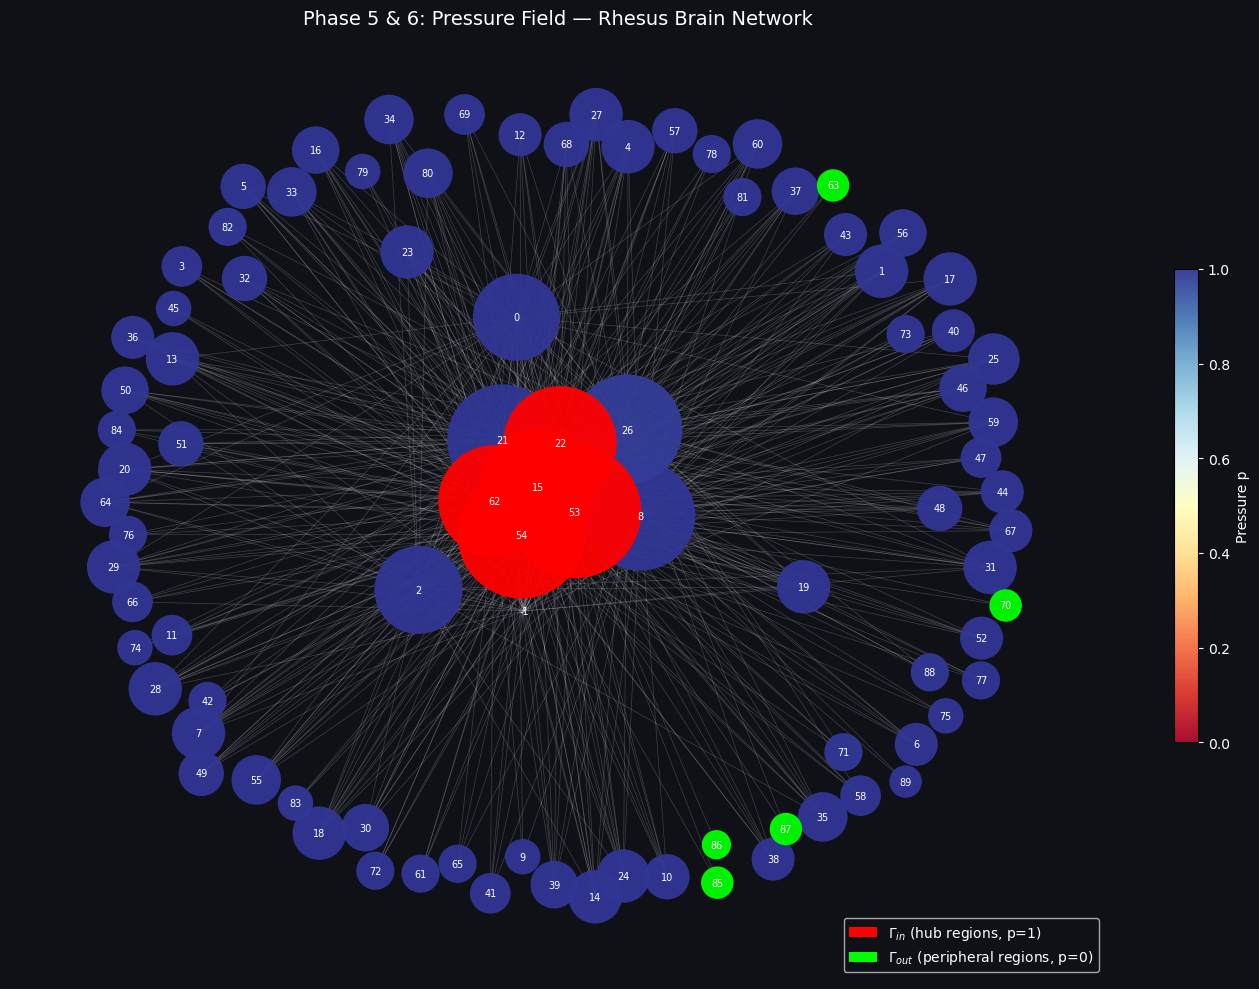

In [72]:
fig, ax = plt.subplots(figsize=(14, 10))
fig.patch.set_facecolor("#0f1117")
ax.set_facecolor("#0f1117")

G_vis4 = nx.Graph()
G_vis4.add_nodes_from(range(n_vertices))
G_vis4.add_edges_from(edges)

degrees_vis4 = dict(G_vis4.degree())
pos4         = nx.spring_layout(G_vis4, seed=42, k=2)
nodelist4    = list(range(n_vertices))

# separate interior, gamma_in, gamma_out
interior     = [v for v in nodelist4 if v not in gamma_in and v not in gamma_out]
int_sizes    = [300 + degrees_vis4[v] * 100 for v in interior]
gin_sizes    = [300 + degrees_vis4[v] * 100 for v in gamma_in]
gout_sizes   = [300 + degrees_vis4[v] * 100 for v in gamma_out]

# edges
nx.draw_networkx_edges(G_vis4, pos4, ax=ax, edge_color="white", width=0.5, alpha=0.2)

# interior nodes colored by pressure
nc = nx.draw_networkx_nodes(G_vis4, pos4, ax=ax, nodelist=interior,
                             node_size=int_sizes,
                             node_color=[p[v] for v in interior],
                             cmap=plt.cm.RdYlBu, alpha=0.95,
                             vmin=0, vmax=1)

# gamma_in — red
nx.draw_networkx_nodes(G_vis4, pos4, ax=ax, nodelist=gamma_in,
                       node_size=gin_sizes,
                       node_color="red", alpha=0.95)

# gamma_out — green
nx.draw_networkx_nodes(G_vis4, pos4, ax=ax, nodelist=gamma_out,
                       node_size=gout_sizes,
                       node_color="lime", alpha=0.95)

# node labels
nx.draw_networkx_labels(G_vis4, pos4, ax=ax, font_color="white", font_size=7)

# colorbar
cb = plt.colorbar(nc, ax=ax, shrink=0.5)
cb.set_label("Pressure p", color="white")
cb.ax.yaxis.set_tick_params(color="white")
plt.setp(cb.ax.yaxis.get_ticklabels(), color="white")

# legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='red',  label='$\\Gamma_{in}$ (hub regions, p=1)'),
    Patch(facecolor='lime', label='$\\Gamma_{out}$ (peripheral regions, p=0)')
]
ax.legend(handles=legend_elements, facecolor="#0f1117",
          labelcolor="white", fontsize=10, loc="lower right")

ax.set_title("Phase 5 & 6: Pressure Field — Rhesus Brain Network",
             color="white", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.savefig("rhesus_phase5_6.png", dpi=150, bbox_inches="tight")
plt.show()

## Phase 6: Quantity of Interest (QoI) Extraction

After solving for the pressure field **p** in Phase 5, we extract a single 
scalar value Q that summarizes the flow through the network.

**Formula:**
Q = Σ k_e × (p_i - p_j) for all edges incident to Γ_out

**What it measures:**
- Total flux exiting through the outlet vertices Γ_out
- How much signal/flow successfully propagated from inlet hubs to peripheral regions
- One number per Monte Carlo sample

**Why it matters:**
- Q is random — it changes every MC step because k changes
- Running Q over N samples gives a distribution
- Mean(Q) = expected flow under uncertain connection strengths
- Var(Q) = how sensitive the network is to uncertainty in connections

**For Rhesus Brain Network:**
- High Q = strong signal propagation from hub regions to periphery
- Low Q = bottlenecks in the network block signal flow
- Distribution of Q tells us how robust brain signal propagation is 
  under uncertain synaptic connection strengths

In [77]:
Q = extract_qoi(p, k, edges, gamma_out)

# Phase 7: Monte Carlo Loop

In [53]:
def monte_carlo_loop_tqdm(L_sigma, lambda_min, edges, n_vertices,
                          gamma_in, gamma_out, edge_weights=None, N=1000):
    """
    Monte Carlo loop with tqdm progress bar.
    Runs Phases 3-6 N times and records Q each step.
    """
    B         = build_incidence_matrix(edges, n_vertices)
    cho_cache = cho_factor(L_sigma)
    Q_samples = np.zeros(N)

    with tqdm(total=N, desc="Monte Carlo", unit="sample") as pbar:
        for i in range(N):
            # Phase 3
            w = np.random.randn(len(edges))
            f = B @ w
            u = cho_solve(cho_cache, lambda_min * f)

            # Phase 4
            k = {(vi, vj): np.exp((u[vi] + u[vj]) / 2) *
                 (edge_weights.get((vi,vj), edge_weights.get((vj,vi), 1.0))
                  if edge_weights else 1.0)
                 for (vi, vj) in edges}

            # Phase 5
            L_k = build_weighted_laplacian(edges, n_vertices, k)
            p   = solve_darcy(L_k, n_vertices, gamma_in, gamma_out)

            # Phase 6
            Q_samples[i] = extract_qoi(p, k, edges, gamma_out)

            pbar.update(1)
            pbar.set_postfix({"mean Q": f"{Q_samples[:i+1].mean():.4f}"})

    print(f"\n✓ Done — {N} samples complete")
    print(f"  Mean Q : {Q_samples.mean():.6f}")
    print(f"  Std Q  : {Q_samples.std():.6f}")
    print(f"  Var Q  : {Q_samples.var():.6f}")

    return Q_samples


# run it
np.random.seed(42)
Q_samples = monte_carlo_loop_tqdm(L_sigma, lambda_min, edges, n_vertices,
                                   gamma_in, gamma_out, edge_weights=None, N=100)

Monte Carlo:   5%|▌         | 5/100 [00:00<00:03, 25.86sample/s, mean Q=-8.9425]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]



Monte Carlo:  10%|█         | 10/100 [00:00<00:03, 22.81sample/s, mean Q=-8.8443]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]



Monte Carlo:  16%|█▌        | 16/100 [00:00<00:03, 25.61sample/s, mean Q=-8.9559]

...

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]



Monte Carlo:  94%|█████████▍| 94/100 [00:04<00:00, 25.42sample/s, mean Q=-9.1240]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]



Monte Carlo: 100%|██████████| 100/100 [00:04<00:00, 22.00sample/s, mean Q=-9.1187]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]


✓ Done — 100 samples complete
  Mean Q : -9.118652
  Std Q  : 0.847600
  Var Q  : 0.718426



=== Monte Carlo Results ===
  Samples : 100
  Mean Q  : -9.118652
  Std Q   : 0.847600
  Var Q   : 0.718426
  Min Q   : -12.258894
  Max Q   : -6.701253
Saved as rhesus_phase7.png


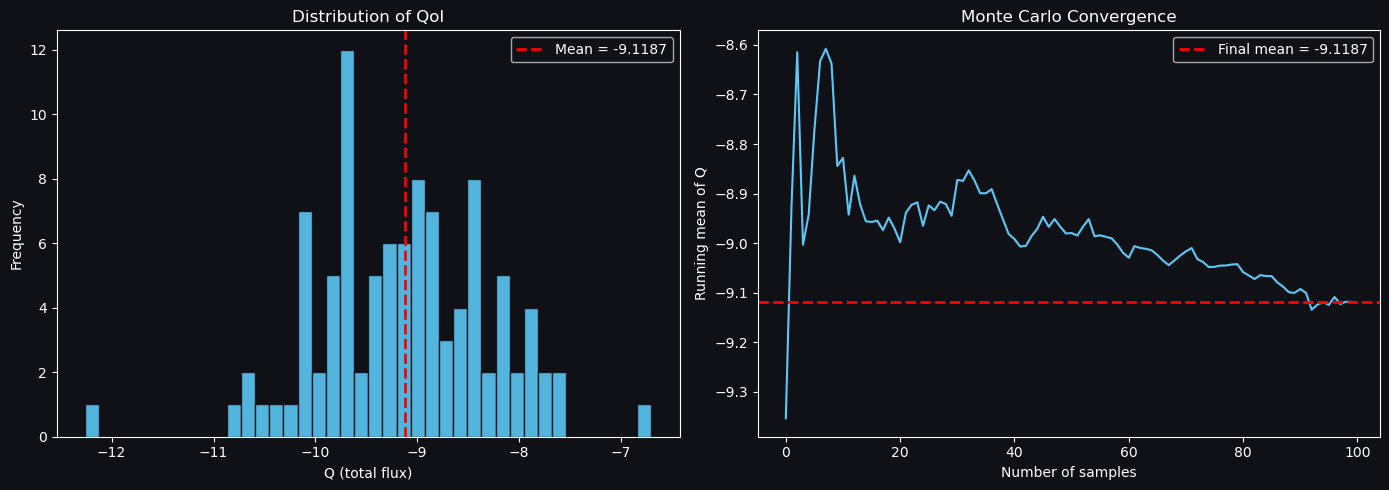

In [73]:
analyze_qoi(Q_samples, save_as="rhesus_phase7.png" )